In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error


In [2]:
df = pd.read_csv("../data/processed/monthly_category_demand.csv")
df['Month'] = pd.to_datetime(df['Month'])

office_df = df[df['Category'] == 'Office Supplies'].copy()
office_df.set_index('Month', inplace=True)

office_df.head()


,Category,Quantity
Month,,
2012-01-01,Office Supplies,997
2012-02-01,Office Supplies,800
2012-03-01,Office Supplies,1093
2012-04-01,Office Supplies,1233
2012-05-01,Office Supplies,1268


In [3]:
train = office_df.iloc[:-6]
test = office_df.iloc[-6:]

print("Train size:", train.shape)
print("Test size:", test.shape)


Train size: (42, 2)
Test size: (6, 2)


In [4]:
model = SARIMAX(
    train['Quantity'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()
print(results.summary())


c:\Users\sruth_5j39l0q\Downloads\Retail_Demand_Forecasting\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sruth_5j39l0q\Downloads\Retail_Demand_Forecasting\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sruth_5j39l0q\Downloads\Retail_Demand_Forecasting\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                           Quantity   No. Observations:                   42
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -106.258
Date:                            Sun, 01 Feb 2026   AIC                            222.515
Time:                                    19:03:20   BIC                            226.056
Sample:                                01-01-2012   HQIC                           222.478
                                     - 06-01-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0835      0.266      0.314      0.753      -0.437       0.604
ma.L1         -1.0000      2.087   

In [5]:
forecast = results.get_forecast(steps=6)
forecast_values = forecast.predicted_mean


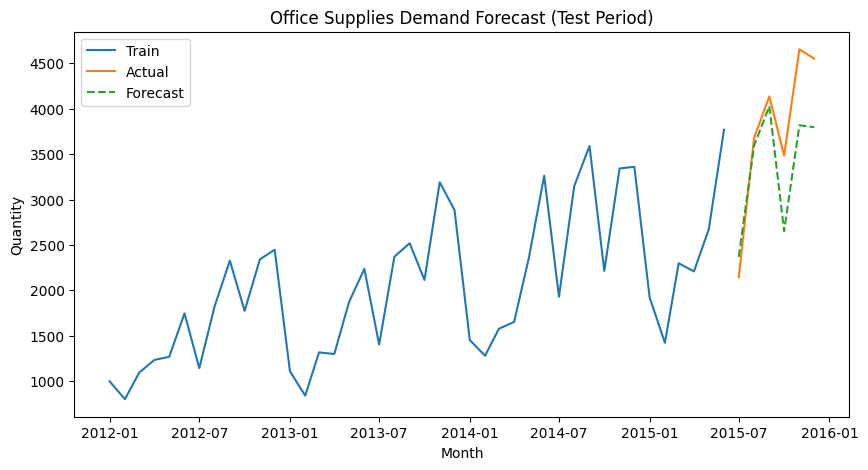

In [6]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train['Quantity'], label='Train')
plt.plot(test.index, test['Quantity'], label='Actual')
plt.plot(test.index, forecast_values, label='Forecast', linestyle='--')

plt.title("Office Supplies Demand Forecast (Test Period)")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.legend()
plt.show()


In [7]:
mape = mean_absolute_percentage_error(
    test['Quantity'],
    forecast_values
)

print(f"MAPE: {mape:.2%}")


MAPE: 12.30%


In [8]:
future_forecast = results.get_forecast(steps=12)
future_values = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()


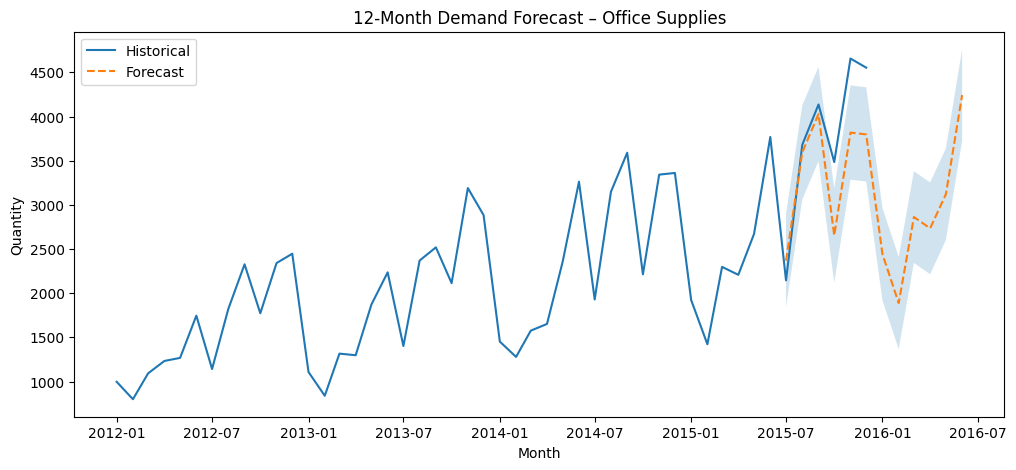

In [9]:
plt.figure(figsize=(12,5))
plt.plot(office_df.index, office_df['Quantity'], label='Historical')
plt.plot(future_values.index, future_values, label='Forecast', linestyle='--')
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2
)

plt.title("12-Month Demand Forecast – Office Supplies")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.legend()
plt.show()


In [10]:
forecast_df = future_values.reset_index()
forecast_df.columns = ['Month', 'Forecasted_Quantity']

forecast_df.to_csv(
    "../outputs/forecasts/office_supplies_12_month_forecast.csv",
    index=False
)
